# 3.3 Composition

Given layouts $A$ and $B$, the group composition layout $R = A \circ B$ satisfies:

**Domain compatibility:**
$$B \preceq R$$

**Functional composition:**
$$\forall c \in \mathbb{Z}(B),\; R(c) = A(B(c))$$

In this formulation, $B$ determines the shape and coordinate sets of the resulting layout by defining the domain of $R$, while $A$ determines the codomain of $R$. The compatibility condition ensures that all coordinates of $B$ can also be used as coordinates of $R$. For admissibility of both group and functional composition, the codomain of $B$ must be compatible with the domain of $A$, which typically means that the codomain of $B$ is a set of coordinates that are congruent to one of the coordinate sets in $\mathbb{Z}(A)$.

In [1]:
from tensor_layouts import *
from tensor_layouts.viz import draw_layout, draw_tv_layout

In [2]:
# Basic composition: R = A ∘ B means R(c) = A(B(c))
A = Layout((4, 8), (1, 4))
B = Layout(6, 2)
R = compose(A, B)
print(f"A = {A}")
print(f"B = {B}")
print(f"R = compose(A, B) = {R}")
print()

# Verify: R(c) = A(B(c)) for all c in domain of B
for c in range(size(B)):
    assert R(c) == A(B(c)), f"Failed at c={c}"
    print(f"  R({c}) = {R(c)},  A(B({c})) = A({B(c)}) = {A(B(c))}")

A = (4, 8) : (1, 4)
B = 6 : 2
R = compose(A, B) = 6 : 2

  R(0) = 0,  A(B(0)) = A(0) = 0
  R(1) = 2,  A(B(1)) = A(2) = 2
  R(2) = 4,  A(B(2)) = A(4) = 4
  R(3) = 6,  A(B(3)) = A(6) = 6
  R(4) = 8,  A(B(4)) = A(8) = 8
  R(5) = 10,  A(B(5)) = A(10) = 10


## 3.3.1 Composition Properties

**Identity Layouts.** For any shape $S$, an identity layout $I_S$ satisfies

$$\forall c \in \mathbb{Z}_S,\; I_S(c) = c.$$

Note that $I_S$ may actually take on any shape $P$ so long as $S \preceq P$. For example, the following are all identity layouts $I_{24}$ and satisfy $L(i) = i$ for all $i \in \mathbb{Z}_{24}$:

$$24 : 1, \quad (4, 6) : (1, 4), \quad (3, (4, 2)) : (1, (3, 12)).$$

For a layout $B$ with codomain $\mathbb{Z}_D$, any $I_D$ serves as a group composition left identity,

$$I_D \circ B = B.$$

For a layout $A$ with domain $\mathbb{Z}_S$, the layout $I_S$ with shape $S$ serves as a group composition right identity,

$$A \circ I_S = A.$$

In [3]:
# Identity layouts I_24: all satisfy L(i) = i for i in Z_24
I_24a = Layout(24, 1)
I_24b = Layout((4, 6), (1, 4))
I_24c = Layout((3, (4, 2)), (1, (3, 12)))

print("Identity layouts I_24:")
for name, L in [("24:1", I_24a), ("(4,6):(1,4)", I_24b), ("(3,(4,2)):(1,(3,12))", I_24c)]:
    vals = [L(i) for i in range(24)]
    assert vals == list(range(24)), f"{name} is not identity!"
    print(f"  {name}: L(i) = i for all i ✓")

print()

# Left identity: I_D ∘ B = B
B = Layout((3, 5), (2, 7))
I_D = Layout(size(B) * 10, 1)  # any I_D with D large enough
result = compose(I_D, B)
print(f"B = {B}")
print(f"I_D ∘ B = {result}")
for c in range(size(B)):
    assert result(c) == B(c)
print("Left identity verified: I_D ∘ B = B")

print()

# Right identity: A ∘ I_S = A
A = Layout((4, 6), (3, 12))
I_S = Layout((4, 6), (1, 4))  # identity layout with shape matching A's domain
result = compose(A, I_S)
print(f"A = {A}")
print(f"A ∘ I_S = {result}")
for c in range(size(A)):
    assert result(c) == A(c)
print("Right identity verified: A ∘ I_S = A")

Identity layouts I_24:
  24:1: L(i) = i for all i ✓
  (4,6):(1,4): L(i) = i for all i ✓
  (3,(4,2)):(1,(3,12)): L(i) = i for all i ✓

B = (3, 5) : (2, 7)
I_D ∘ B = (3, 5) : (2, 7)
Left identity verified: I_D ∘ B = B

A = (4, 6) : (3, 12)
A ∘ I_S = (4, 6) : (3, 12)
Right identity verified: A ∘ I_S = A


**Associative Property.** Given layouts $A$, $B$, and $C$, and the condition

$$\text{image}(C) \subseteq \mathbb{Z}(B) \quad \text{and} \quad \text{image}(B) \subseteq \mathbb{Z}(A),$$

then

$$A \circ (B \circ C) = (A \circ B) \circ C.$$

Note that composition is still often possible when the above condition is not satisfied, but associativity may be lost. For instance,

$$(5, 3) : (1, 7) \circ [4 : 1 \circ 2 : 5] = (5, 3) : (1, 7) \circ 2 : 5 = 2 : 7$$

$$[(5, 3) : (1, 7) \circ 4 : 1] \circ 2 : 5 = 4 : 1 \circ 2 : 5 = 2 : 5$$

yield different results because the range of $2 : 5$ is not contained in the domain of $4 : 1$.

In [4]:
# Associativity holds when image conditions are met
A = Layout((4, 3), (2, 8))
B = Layout(6, 2)
C = Layout(3, 1)

lhs = compose(A, compose(B, C))  # A ∘ (B ∘ C)
rhs = compose(compose(A, B), C)  # (A ∘ B) ∘ C
print(f"A = {A}, B = {B}, C = {C}")
print(f"A ∘ (B ∘ C) = {lhs}")
print(f"(A ∘ B) ∘ C = {rhs}")
for c in range(size(C)):
    assert lhs(c) == rhs(c)
print("Associativity holds!")

print()

# Associativity can fail when image conditions are violated
A2 = Layout((5, 3), (1, 7))
B2 = Layout(4, 1)
C2 = Layout(2, 5)

lhs2 = compose(A2, compose(B2, C2))  # A ∘ (B ∘ C)
rhs2 = compose(compose(A2, B2), C2)  # (A ∘ B) ∘ C
print(f"A = {A2}, B = {B2}, C = {C2}")
print(f"A ∘ (B ∘ C) = {lhs2}")
print(f"(A ∘ B) ∘ C = {rhs2}")
print(f"Results differ: {lhs2} vs {rhs2}")
print("Associativity fails because image(C) ⊄ Z(B): range of 2:5 is {{0,5}} but B=4:1 has domain Z_4.")

A = (4, 3) : (2, 8), B = 6 : 2, C = 3 : 1
A ∘ (B ∘ C) = 3 : 4
(A ∘ B) ∘ C = 3 : 4
Associativity holds!

A = (5, 3) : (1, 7), B = 4 : 1, C = 2 : 5
A ∘ (B ∘ C) = 2 : 7
(A ∘ B) ∘ C = 2 : 5
Results differ: 2 : 7 vs 2 : 5
Associativity fails because image(C) ⊄ Z(B): range of 2:5 is {{0,5}} but B=4:1 has domain Z_4.


## 3.3.2 Evaluation and Restrictions

The evaluation of group composition can be constructively derived from the layout evaluation operations. We determine a set of admissibility conditions on layouts $A$ and $B$ that are required to successfully compute group composition.

**Base Case.** Let $B = s : d$ with $s \in \mathbb{Z}_+$ and $d \in \mathbb{N}$. Let $A = S : D = (S_0, S_1, \ldots, S_R) : (D_0, D_1, \ldots, D_R)$. Define the exclusive prefix-product of $S$ as $\overline{S}_r = \prod_{k=0}^{r-1} S_k$. The result $R = S' : D'$ has:

$$S'_r = \frac{S_r}{\delta_r}, \quad D'_r = D_r \cdot \delta_r$$

where $\delta_r = \lceil d / \overline{S}_r \rceil$ and $\rho_r = \lceil \overline{S}_r / d \rceil$.

This requires two divisibility conditions:

**Stride divisibility condition:** $\overline{S}_r \mid d$ or $d \mid \overline{S}_r$ for each $r$.

**Shape divisibility condition:** $\lceil \overline{S}_r / d \rceil \mid s$ for each $r$.

**Reductive Case: Distributive.** To express more general compositions in terms of the base case, we use a distributive property of the composition operation over concatenation of sublayouts of $B$:

$$A \circ B = A \circ (B_0, B_1, \ldots) = (A \circ B_0, A \circ B_1, \ldots)$$

In [5]:
# Base case: B = s:d (rank-1), A is multi-rank
# The result S'_r = S_r / delta_r, D'_r = D_r * delta_r
A = Layout((4, 6), (1, 4))
B = Layout(6, 4)   # every 4th element of A, keep 6
R = compose(A, B)

print(f"A = {A}  (4x6 col-major, identity layout I_24)")
print(f"B = {B}  (every 4th element, keep 6)")
print(f"R = A ∘ B = {R}")
print()
print("Verification:")
for i in range(size(B)):
    print(f"  R({i}) = {R(i)},  A(B({i})) = A({B(i)}) = {A(B(i))}")
    assert R(i) == A(B(i))

A = (4, 6) : (1, 4)  (4x6 col-major, identity layout I_24)
B = 6 : 4  (every 4th element, keep 6)
R = A ∘ B = 6 : 4

Verification:
  R(0) = 0,  A(B(0)) = A(0) = 0
  R(1) = 4,  A(B(1)) = A(4) = 4
  R(2) = 8,  A(B(2)) = A(8) = 8
  R(3) = 12,  A(B(3)) = A(12) = 12
  R(4) = 16,  A(B(4)) = A(16) = 16
  R(5) = 20,  A(B(5)) = A(20) = 20


In [6]:
# Distributive property: A ∘ (B0, B1, ...) = (A ∘ B0, A ∘ B1, ...)
A = Layout((4, 8), (1, 4))
B = Layout((4, 3), (2, 8))
R = compose(A, B)

# Compose A with each mode of B separately
R0 = compose(A, mode(B, 0))
R1 = compose(A, mode(B, 1))

print(f"A = {A}")
print(f"B = {B}")
print(f"A ∘ B = {R}")
print(f"A ∘ B0 = {R0}, A ∘ B1 = {R1}")
print()

# Verify pointwise
for i in range(size(mode(B, 0))):
    for j in range(size(mode(B, 1))):
        assert R(i, j) == A(B(i, j)), f"Failed at ({i},{j})"
print("Distributive property verified: compose distributes over modes of B.")

A = (4, 8) : (1, 4)
B = (4, 3) : (2, 8)
A ∘ B = (4, 3) : (2, 8)
A ∘ B0 = 4 : 2, A ∘ B1 = 3 : 8

Distributive property verified: compose distributes over modes of B.


## 3.3.3 Intuition and Divisibility

Compositions with rank-1 left-hand layouts $A$ are trivial because $\overline{S}_R$ does not appear:

$$(S_0) : (D_0) \circ s : d = s : D_0 \cdot d.$$

In this case, there are no non-trivial divisibility checks. Note that this means group composition is still possible even when $\text{image}(B) \not\subseteq \mathbb{Z}(A)$:

$$7 : 11 \circ 3 : 4 = 3 : 44,$$

and $B$ does not need to be mutually disjoint in order to be distributive:

$$7 : 11 \circ (3, 5) : (6, 3) = (3, 5) : (66, 33).$$

In [7]:
# Rank-1 A: trivially composes, just scales the stride
A = Layout(7, 11)

R1 = compose(A, Layout(3, 4))
print(f"7:11 ∘ 3:4 = {R1}")  # 3:44
assert all(R1(i) == 11 * (4 * i) for i in range(3))

R2 = compose(A, Layout((3, 5), (6, 3)))
print(f"7:11 ∘ (3,5):(6,3) = {R2}")  # (3,5):(66,33)
for i in range(3):
    for j in range(5):
        assert R2(i, j) == A(Layout((3, 5), (6, 3))(i, j))

7:11 ∘ 3:4 = 3 : 44
7:11 ∘ (3,5):(6,3) = (3, 5) : (66, 33)


For compositions with layouts $A$ of greater rank, the intuitive strategy involves two steps:

- Determine an intermediate layout that produces every $d$th element of $A$ by "dividing out" the first $d$ elements from $A$.
- Fix the size of the intermediate strided layout to $s$ by "keeping" the first $s$ elements.

For example,

$$(4, 6, 8, 10) : (2, 3, 5, 7) \circ 6 : 12$$

is equivalent to

$$(4, 6, 8, 10) : (2, 3, 5, 7) \circ 6 : 12 = (1, 2, 8, 10) : (X, 9, 5, 7) \circ 6 : 1,$$

where the first 12 elements of $A$ are "divided out," and the strides are scaled accordingly. Then, the first 6 elements of the modified layout are "kept," resulting in:

$$(1, 2, 8, 10) : (X, 9, 5, 7) \circ 6 : 1 = (2, 3) : (9, 5).$$

Alternatively, we can "keep" the first $6 \cdot 12$ elements and then "divide out" the first 12, as follows:

$$(4, 6, 8, 10) : (2, 3, 5, 7) \circ 6 : 12 = (4, 6, 3) : (2, 3, 5) \circ 6 : 12 = (2, 3) : (9, 5).$$

In [8]:
# The "divide out" and "keep" intuition
A = Layout((4, 6, 8, 10), (2, 3, 5, 7))
B = Layout(6, 12)
R = compose(A, B)
print(f"A = {A}")
print(f"B = {B}")
print(f"A ∘ B = {R}")
print()

# Verify
for i in range(size(B)):
    assert R(i) == A(B(i)), f"Failed at i={i}"
    print(f"  R({i}) = {R(i)},  A({B(i)}) = {A(B(i))}")

A = (4, 6, 8, 10) : (2, 3, 5, 7)
B = 6 : 12
A ∘ B = (2, 3) : (9, 5)

  R(0) = 0,  A(0) = 0
  R(1) = 9,  A(12) = 9
  R(2) = 5,  A(24) = 5
  R(3) = 14,  A(36) = 14
  R(4) = 10,  A(48) = 10
  R(5) = 19,  A(60) = 19


**Violations of Divisibility Conditions.** Certain compositions violate the stride or shape divisibility conditions. For example,

$$(4, 6, 8) : (2, 3, 5) \circ 6 : 3$$

violates the stride divisibility condition because $\overline{S}_1 = 4$ and $d = 3$ are not divisible. There is no layout that can represent every third element of the layout $(4, 6, 8) : (2, 3, 5)$.

Similarly, the composition

$$(4, 6, 8) : (2, 3, 5) \circ 6 : 1$$

violates the shape divisibility condition, since $\lceil \overline{S}_1 / d \rceil = \lceil 4/1 \rceil = 4$ does not divide $s = 6$. There is no layout that can represent the first 6 elements of $(4, 6, 8) : (2, 3, 5)$.

Ultimately, this means CuTe layouts are not strictly closed under group composition. However, in practice, violations of divisibility conditions are often due to conceptual application errors, layout/hardware incompatibilities, programmer error, and other such issues.

In [9]:
# Divisibility violations

# Stride divisibility violation: S1_bar = 4, d = 3, neither divides the other
try:
    bad1 = compose(Layout((4, 6, 8), (2, 3, 5)), Layout(6, 3))
    print(f"(4,6,8):(2,3,5) ∘ 6:3 = {bad1} (library may handle gracefully)")
except Exception as ex:
    print(f"Stride divisibility violation: {ex}")

# Shape divisibility violation: ceil(4/1) = 4 does not divide s = 6
try:
    bad2 = compose(Layout((4, 6, 8), (2, 3, 5)), Layout(6, 1))
    print(f"(4,6,8):(2,3,5) ∘ 6:1 = {bad2} (library may handle gracefully)")
except Exception as ex:
    print(f"Shape divisibility violation: {ex}")

Stride divisibility violation: complement: shape 4 and stride 3 are not divisible
(4,6,8):(2,3,5) ∘ 6:1 = 4 : 2 (library may handle gracefully)


**Apparent Violations.** Consider the composition

$$(4, 2, 8) : (3, 12, 97) \circ 3 : 3,$$

which seemingly violates the stride divisibility condition because $\overline{S}_1 = 4$ and $d = 3$ are not divisible. This issue can be resolved by coalescing $A$ and truncating $A$. The equivalent composition produces the result

$$(4, 2, 8) : (3, 12, 97) \circ 3 : 3 = (8, 8) : (3, 97) \circ 3 : 3 = (8) : (3) \circ 3 : 3 = 3 : 9.$$

However, the following compositions fail divisibility conditions:

$$(4, 2, 8) : (3, 12, 97) \circ 4 : 3$$
$$(4, 2, 8) : (3, 15, 97) \circ 3 : 3$$

The example on the left cannot be sufficiently truncated, while the example on the right cannot be coalesced.

In [10]:
# Apparent violation resolved by coalescing + truncation
A_orig = Layout((4, 2, 8), (3, 12, 97))
A_coal = coalesce(A_orig)
print(f"Original A:  {A_orig}")
print(f"Coalesced A: {A_coal}")
print()

# The coalesced form is (8, 8):(3, 97). With B = 3:3, (s-1)*d = 2*3 = 6 < 8,
# so only the first mode of A contributes. We truncate to just 8:3.
A_trunc = Layout(8, 3)
print(f"Truncated A: {A_trunc}  (only first mode needed since (s-1)*d = 6 < 8)")

R = compose(A_trunc, Layout(3, 3))
print(f"Truncated A ∘ 3:3 = {R}")
print()

# Verify via direct evaluation on the original
B = Layout(3, 3)
for i in range(size(B)):
    assert R(i) == A_orig(B(i)), f"Failed at i={i}"
print("Verified: R(i) = A(B(i)) for all i")
print()

# The left example fails: cannot be sufficiently truncated
try:
    compose(Layout((4, 2, 8), (3, 12, 97)), Layout(4, 3))
    print("(4,2,8):(3,12,97) ∘ 4:3 succeeded unexpectedly")
except Exception as ex:
    print(f"(4,2,8):(3,12,97) ∘ 4:3 fails: {type(ex).__name__}")

# The right example fails: cannot be coalesced (strides 3 and 15 not contiguous)
A_bad = Layout((4, 2, 8), (3, 15, 97))
print(f"coalesce({A_bad}) = {coalesce(A_bad)}  (modes don't merge)")
try:
    compose(A_bad, Layout(3, 3))
    print("(4,2,8):(3,15,97) ∘ 3:3 succeeded unexpectedly")
except Exception as ex:
    print(f"(4,2,8):(3,15,97) ∘ 3:3 fails: {type(ex).__name__}")

Original A:  (4, 2, 8) : (3, 12, 97)
Coalesced A: (8, 8) : (3, 97)

Truncated A: 8 : 3  (only first mode needed since (s-1)*d = 6 < 8)
Truncated A ∘ 3:3 = 3 : 9

Verified: R(i) = A(B(i)) for all i

(4,2,8):(3,12,97) ∘ 4:3 fails: ValueError
coalesce((4, 2, 8) : (3, 15, 97)) = (4, 2, 8) : (3, 15, 97)  (modes don't merge)
(4,2,8):(3,15,97) ∘ 3:3 fails: ValueError


## 3.3.4 Application: Partitioning Example

Composition lies at the heart of the CuTe layout algebra, enabling operations such as reshaping, restriding, permuting, partitioning, tiling, and extracting sublayouts. This section demonstrates the application of composition for partitioning a data tensor using an arbitrary thread-value pattern.

Consider a layout of data that refines shape $(8, 8)$. We aim to partition this data using the thread-value pattern shown in Figure 6, which is the logical partitioning pattern of a specific Ampere Tensor Core. The thread-value partitioning pattern for this instruction can be represented by the layout

```
ThrValLayoutC: ((4, 8), 2) : ((16, 1), 8),
```

which acts as a map from `(thread_idx, value_idx)` to the 1D coordinate within the $8 \times 8$ matrix.

Any $8 \times 8$ data layout can be permuted by composing it with the thread-value ThrValLayoutC. Each composition produces a layout compatible with shape $(32, 2)$ and defines the mapping between `(thread_idx, value_idx)` and data offsets.

| Data Name | Data Layout 8x8 (A) | TV Layout 32x2 (B) | Result 32x2 (R) |
|-----------|---------------------|--------------------|-----------------|
| ColMajor | $(8, 8) : (1, 8)$ | $((4, 8), 2) : ((16, 1), 8)$ | $((4, 8), 2) : ((16, 1), 8)$ |
| RowMajor | $(8, 8) : (8, 1)$ | $((4, 8), 2) : ((16, 1), 8)$ | $((4, 8), 2) : ((2, 8), 1)$ |
| Padded | $(8, 8) : (1, 9)$ | $((4, 8), 2) : ((16, 1), 8)$ | $((4, 8), 2) : ((18, 1), 9)$ |

ThrValLayoutC: ((4, 8), 2) : ((16, 1), 8)
  Domain: (32, 2) = (32 threads, 2 values)
  Codomain: Z_{64} (8x8 = 64 elements)

Thread-Value partitioning pattern (TV layout):


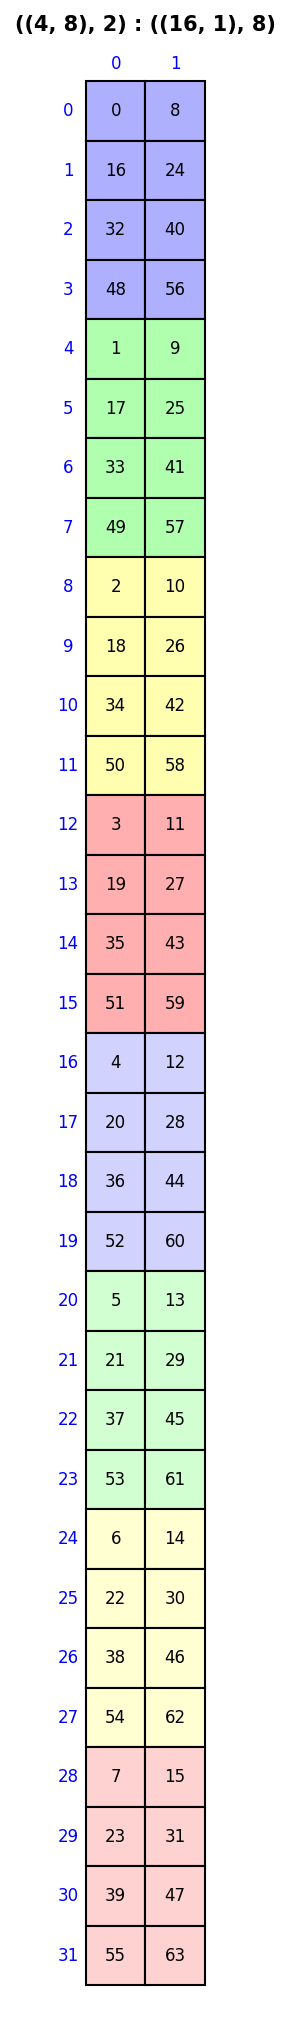

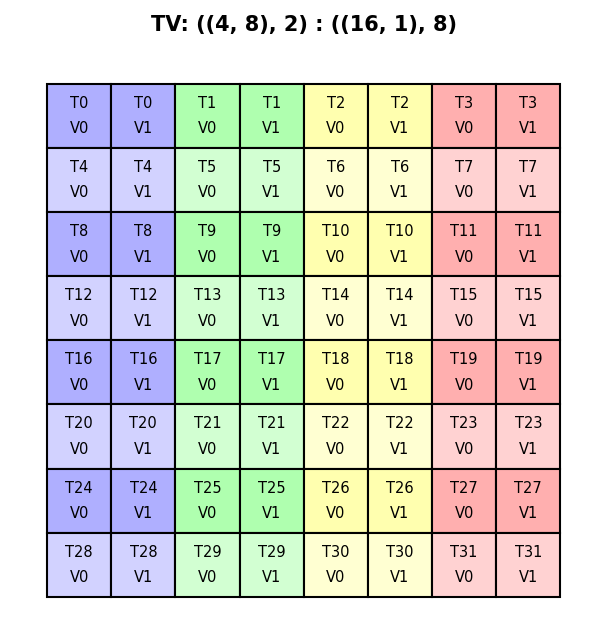

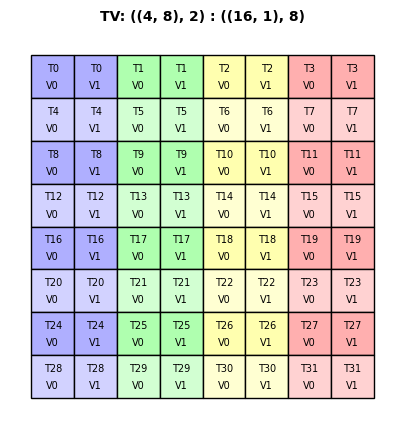

In [11]:
# Thread-Value Layout for Ampere FP64 Tensor Core C-matrix
# Maps (thread_idx, value_idx) -> 1D coordinate in 8x8 matrix
tv_layout = Layout(((4, 8), 2), ((16, 1), 8))
print(f"ThrValLayoutC: {tv_layout}")
print(f"  Domain: ({size(mode(tv_layout, 0))}, {size(mode(tv_layout, 1))}) = (32 threads, 2 values)")
print(f"  Codomain: Z_{{64}} (8x8 = 64 elements)")
print()

# Visualize the TV layout — this shows which thread and value own each element
print("Thread-Value partitioning pattern (TV layout):")
draw_layout(tv_layout, colorize=True)
draw_tv_layout(tv_layout, colorize=True)

In [12]:
# Compose various 8x8 data layouts with the TV layout

# Column-major data
data_col = Layout((8, 8), (1, 8))
R_col = compose(data_col, tv_layout)
print(f"ColMajor:  {data_col}")
print(f"  Result:  {R_col}")
for t in range(size(mode(tv_layout, 0))):
    for v in range(size(mode(tv_layout, 1))):
        assert R_col(t, v) == data_col(tv_layout(t, v))
print("  Verified!")
print()

# Row-major data
data_row = Layout((8, 8), (8, 1))
R_row = compose(data_row, tv_layout)
print(f"RowMajor:  {data_row}")
print(f"  Result:  {R_row}")
for t in range(size(mode(tv_layout, 0))):
    for v in range(size(mode(tv_layout, 1))):
        assert R_row(t, v) == data_row(tv_layout(t, v))
print("  Verified!")
print()

# Padded data (stride 9 instead of 8 for column)
data_pad = Layout((8, 8), (1, 9))
R_pad = compose(data_pad, tv_layout)
print(f"Padded:    {data_pad}")
print(f"  Result:  {R_pad}")
for t in range(size(mode(tv_layout, 0))):
    for v in range(size(mode(tv_layout, 1))):
        assert R_pad(t, v) == data_pad(tv_layout(t, v))
print("  Verified!")

ColMajor:  (8, 8) : (1, 8)
  Result:  ((4, 8), 2) : ((16, 1), 8)
  Verified!

RowMajor:  (8, 8) : (8, 1)
  Result:  ((4, 8), 2) : ((2, 8), 1)
  Verified!

Padded:    (8, 8) : (1, 9)
  Result:  ((4, 8), 2) : ((18, 1), 9)
  Verified!


In [13]:
# The compose-and-slice pattern:
# Given a data layout and a TV layout, compose them and then
# slice by thread_id to get each thread's view of the data.

data_layout = Layout((8, 8), (1, 8))  # column-major 8x8
smem_tv = compose(data_layout, tv_layout)

print(f"Data layout: {data_layout}")
print(f"TV layout:   {tv_layout}")
print(f"Composed:    {smem_tv}")
print()

# Slice by thread to get each thread's value layout
for thr_id in [0, 1, 7, 31]:
    smem_v = smem_tv(thr_id, None)  # fix thread, keep value dimension
    offsets = [smem_v(v) for v in range(size(smem_v))]
    print(f"  Thread {thr_id:2d}: layout = {smem_v}, offsets = {offsets}")

Data layout: (8, 8) : (1, 8)
TV layout:   ((4, 8), 2) : ((16, 1), 8)
Composed:    ((4, 8), 2) : ((16, 1), 8)

  Thread  0: layout = (2,) : (8,), offsets = [0, 8]
  Thread  1: layout = (2,) : (8,), offsets = [0, 8]
  Thread  7: layout = (2,) : (8,), offsets = [0, 8]
  Thread 31: layout = (2,) : (8,), offsets = [0, 8]


The code above demonstrates a common pattern that uses thread-value partitioning:

```python
smem_data = Tensor(MyAccessor, MyLayout8x8)        # Tensor:    Coord -> Offset
tv_layout = Layout(((4,8),2), ((16,1),8))          # TV Layout: (Thr,Val) -> Coord
smem_tv   = composition(smem_data, tv_layout)      # Compose:   (Thr,Val) -> Offset
smem_v    = smem_tv[thr_id, None]                  # Slice by thread to get subtensor
copy(smem_v, rmem_data)                            # Copy to register tensor/array
```

This pattern occurs extremely often in SIMD programming, where each processing element receives a symmetric partition of some parent data. In general, CuTe recognizes that arbitrary partitioning can be defined as composition (permutation and/or reshaping) followed by slicing. Since the partitioning pattern is very often compile-time metadata related to instructions or optimization parameters and the slice is very often a runtime program identifier index, this pattern is much more capable of propagating static information and reducing runtime overhead.

## 3.3.5 By-mode Composition and Tilers

Group composition can be applied by-mode, enabling operations on subdomains of layouts. For instance, it is often desirable to apply composition on the rows of a matrix and the columns of a matrix independently.

**Definition 3.1.** A *Tiler* is an HTuple(Tile), where each Tile is
- a Layout $S : D$, or
- an Integer $S$, treated equivalently to the layout $S : 1$.

This definition means that all layouts are tilers, all integers are tilers, and it provides for shapes like $(4, 8)$ to be used as tilers.

Additionally, there is an equivalence between composition of tilers and composition of coordinate layouts. Specifically, all of the following objects should be considered equivalent when used in composition:

$$(4, 8) \equiv \langle 4, 8 \rangle \equiv (4 : 1, 8 : 1) \equiv (4, 8) : (e_0, e_1)$$

L = (8, 16) : (1, 8)  (8x16 column-major)
  size = 128

Tiler <4:1, 8:1> (first 4 rows, first 8 cols):
  L ∘ T = (4, 8) : (1, 8)
  size = 32


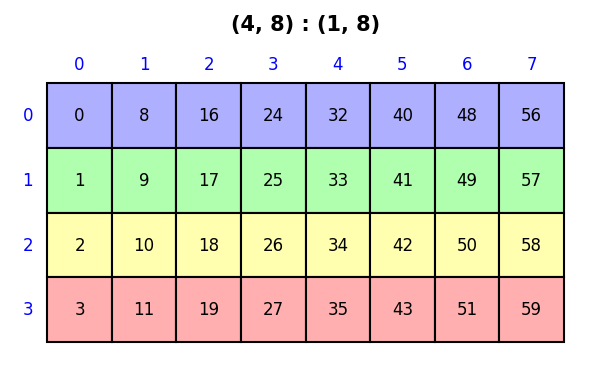

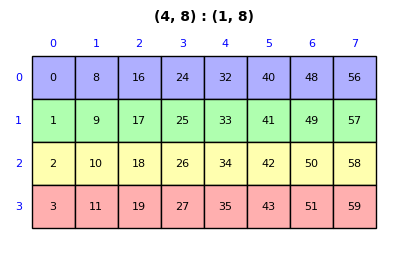

In [14]:
# Tilers: by-mode composition
# A tiler (T0, T1) applied to layout L = (M, N):(X, Y) composes
# each mode independently: (M:X ∘ T0, N:Y ∘ T1)

# Start with an 8x16 column-major layout
L = Layout((8, 16), (1, 8))
print(f"L = {L}  (8x16 column-major)")
print(f"  size = {size(L)}")
print()

# Tiler (4, 8): extract first 4 rows and first 8 columns
# This is equivalent to Tile(4:1, 8:1)
T1 = Tile(Layout(4, 1), Layout(8, 1))
R1 = compose(L, T1)
print(f"Tiler <4:1, 8:1> (first 4 rows, first 8 cols):")
print(f"  L ∘ T = {R1}")
print(f"  size = {size(R1)}")
draw_layout(R1, colorize=True)

L = (8, 16) : (1, 8)  (8x16 column-major)

Tiler <(2,2):(1,4), 8:1>:
  L ∘ T = ((2, 2), 8) : ((1, 4), 8)


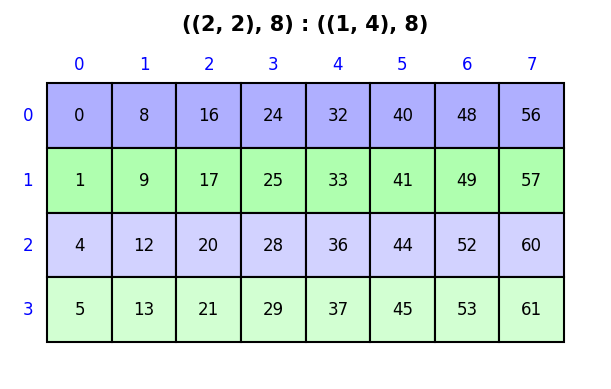

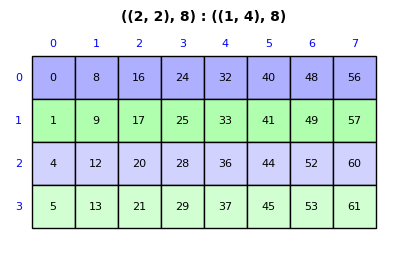

In [15]:
# More interesting tilers that extract non-contiguous patterns

L = Layout((8, 16), (1, 8))
print(f"L = {L}  (8x16 column-major)")
print()

# Tiler <(2,2):(1,4), 8:1> — extract rows {0,1,4,5} and first 8 cols
T2 = Tile(Layout((2, 2), (1, 4)), Layout(8, 1))
R2 = compose(L, T2)
print(f"Tiler <(2,2):(1,4), 8:1>:")
print(f"  L ∘ T = {R2}")
draw_layout(R2, colorize=True)

Tiler <(2,2):(1,4), 8:2>:
  L ∘ T = ((2, 2), 8) : ((1, 4), 16)


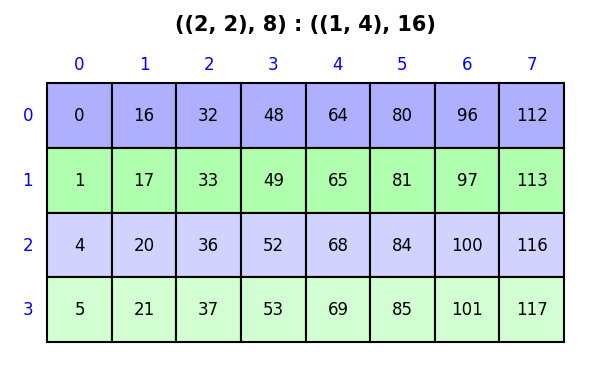

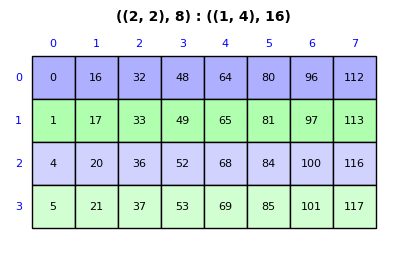

In [16]:
# Tiler <(2,2):(1,4), 8:2> — extract rows {0,1,4,5} and every-other column
T3 = Tile(Layout((2, 2), (1, 4)), Layout(8, 2))
R3 = compose(L, T3)
print(f"Tiler <(2,2):(1,4), 8:2>:")
print(f"  L ∘ T = {R3}")
draw_layout(R3, colorize=True)

Tiler <4:2, 8:2>:
  L ∘ T = (4, 8) : (2, 16)


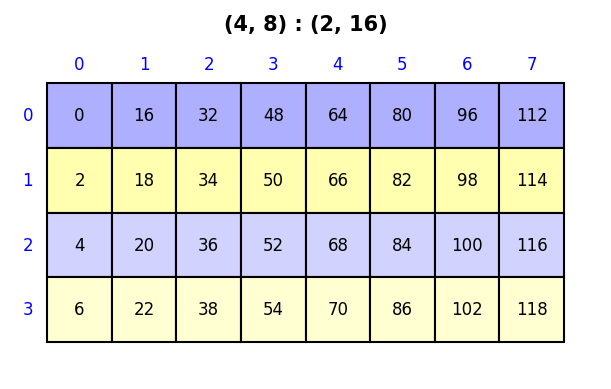

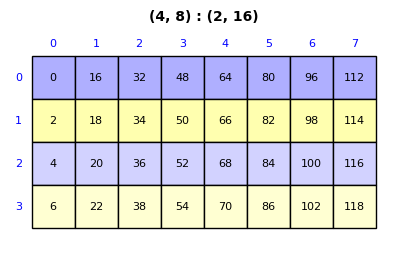

In [17]:
# Tiler <4:2, 8:2> — every-other row and every-other column
T4 = Tile(Layout(4, 2), Layout(8, 2))
R4 = compose(L, T4)
print(f"Tiler <4:2, 8:2>:")
print(f"  L ∘ T = {R4}")
draw_layout(R4, colorize=True)

L_row = (8, 16) : (16, 1)  (8x16 row-major)
Tiler <4:1, 8:1> on row-major:
  L_row ∘ T = (4, 8) : (16, 1)

Verified: tiler correctly extracts 4x8 submatrix from row-major 8x16.


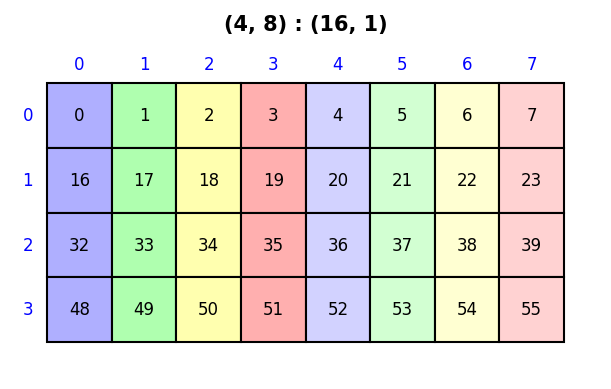

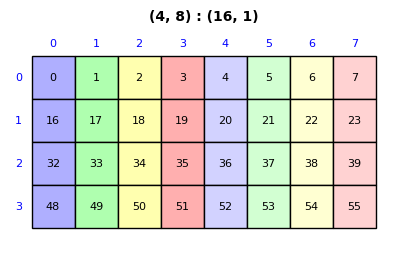

In [18]:
# Verify that tilers work the same on different data layouts
# Apply the same tiler to row-major data
L_row = Layout((8, 16), (16, 1))
print(f"L_row = {L_row}  (8x16 row-major)")

T = Tile(Layout(4, 1), Layout(8, 1))
R_row = compose(L_row, T)
print(f"Tiler <4:1, 8:1> on row-major:")
print(f"  L_row ∘ T = {R_row}")
print()

# Verify: R(i,j) = L(i,j) for the first 4 rows and 8 cols
# The tiler <4:1, 8:1> selects the first 4 elements of mode 0
# and first 8 elements of mode 1
for i in range(4):
    for j in range(8):
        assert R_row(i, j) == L_row(i, j)
print("Verified: tiler correctly extracts 4x8 submatrix from row-major 8x16.")
draw_layout(R_row, colorize=True)